In [1]:
import numpy as np
import pickle
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('text', usetex=True)

In [2]:
n_inp = 8
n_copies= 1
l = 0.05
u = 2
T = 10
V = 100
w_ls = 1
w_var = 1e-4

path = Path() / "Results"
ham_name = "ising_ham_J"
locality = 3

In [3]:
n_pars_1 = 1789
ansatz_info_1 = "%d-local_nonneighbouring_Paulies" %locality
info_1 = f"{ham_name}-{ansatz_info_1}-" + ("n=%d-c=%d-w_ls=%.1f-w_var=%.4f-n_pars=%d" %(n_inp, n_copies, w_ls, w_var, n_pars_1)).replace(" ", "")
file_name_1 = str((path / (info_1 + ".dict")).resolve())

with open(file_name_1, 'rb') as fp:
    data_dict_loaded_1 = pickle.load(fp)

labels_test_1 = data_dict_loaded_1["labels_test"]
expecs_test_1 = data_dict_loaded_1["expecs_test"]
expecs_der_test_1 = data_dict_loaded_1["expecs_der_test"]
disps_test_1 = data_dict_loaded_1["disps_test"]
CFIs_test_1 = data_dict_loaded_1["CFIs_test"]
QFIs_1 = data_dict_loaded_1["QFIs"]

In [5]:
n_pars_2 = 90
ansatz_info_2 = "%d-local_neighbouring-chain-with_symms" %locality
info_2 = f"{ham_name}-{ansatz_info_2}-" + ("n=%d-c=%d-w_ls=%.1f-w_var=%.4f-n_pars=%d" %(n_inp, n_copies, w_ls, w_var, n_pars_2)).replace(" ", "")
file_name_2 = str((path / (info_2 + ".dict")).resolve())

with open(file_name_2, 'rb') as fp:
    data_dict_loaded_2 = pickle.load(fp)

labels_test_2 = data_dict_loaded_2["labels_test"]
expecs_test_2 = data_dict_loaded_2["expecs_test"]
expecs_der_test_2 = data_dict_loaded_2["expecs_der_test"]
disps_test_2 = data_dict_loaded_2["disps_test"]
CFIs_test_2 = data_dict_loaded_2["CFIs_test"]
QFIs_2 = data_dict_loaded_2["QFIs"]

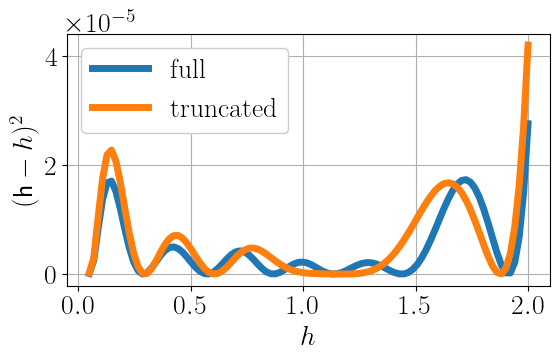

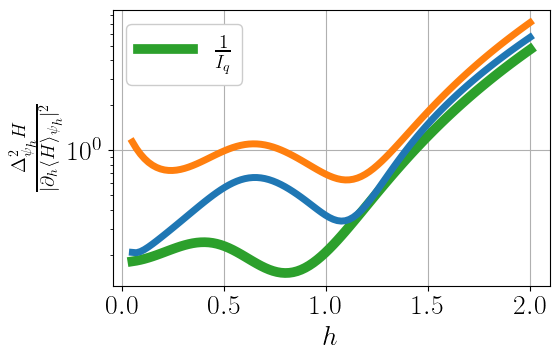

In [6]:
plt.figure(figsize=(6, 4))
plt.rcParams['axes.axisbelow'] = True
plt.plot(labels_test_1, (labels_test_1 - expecs_test_1)**2, linewidth=5, zorder=2, label="full") # , color="dodgerblue"
plt.plot(labels_test_2, (labels_test_2 - expecs_test_2)**2, linewidth=5, zorder=2, label="truncated") # , color="dodgerblue"
plt.xlabel(r"$h$")
plt.ylabel(r"$(\mathsf{h} - h)^2$")
# plt.yscale("log")
plt.grid()
plt.legend(framealpha=1)
plt.tight_layout()
# plt.savefig(str((path / "ising-chain-est.pdf").resolve()), transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 4))
plt.rcParams['axes.axisbelow'] = True
plt.plot(labels_test_1, disps_test_1/expecs_der_test_1**2, linewidth=5, zorder=3)
plt.plot(labels_test_2, disps_test_2/expecs_der_test_2**2, linewidth=5, zorder=3)
# plt.plot(labels_test, 1/CFIs_test, linestyle="--", linewidth=3, zorder=2, label=r"$\frac{1}{I_c}$")
plt.plot(labels_test_1, 1/QFIs_1, linestyle="-", linewidth=7, color="tab:green", zorder=1, label=r"$\frac{1}{I_q}$")
plt.xlabel(r"$h$")
plt.ylabel(r"$\frac{\Delta^2_{\psi_h} H}{|\partial_h \langle H \rangle_{\psi_h}|^2}$")
plt.grid()
plt.yscale("log")
plt.tight_layout()
plt.legend(framealpha=1, loc=0)
# plt.savefig(str((path / "ising-chain-var.pdf").resolve()), transparent=True, bbox_inches='tight')
plt.show()